<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C5_Ejercicio_Integrador_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ALUMNA: SANDRA VARGAS**
# Sección 4: Ejercicio Integrador y Publicación en el Foro

**Objetivo**: Aplicar todas las técnicas de limpieza y transformación de datos vistas en la clase a un dataset real y fomentar la discusión en el foro.

**4.1. Ejercicio Integrador**

Supongamos que trabajamos en una empresa de análisis financiero y tenemos un dataset con información de clientes bancarios. Nuestro objetivo es preparar los datos para un modelo de predicción de solvencia financiera.

**Dataset para el ejercicio**

| Cliente | Edad | Ingresos | Historial de Pagos | Categoría |
|---|---|---|---|---|
| 1 | 25 | 50000 | Bueno | A |
| 2 | 40 | 60000 | Regular | B |
| 3 | 35 | 70000 | Malo | C |
| 4 | 50 | 80000 | Bueno | A |
| 5 | 30 | 45000 | Regular | B |
| 6 | 45 | 85000 | Malo | C |
| 7 | 38 | 72000 | Bueno | A |
| 8 | 29 | 48000 | Regular | B |

**Tareas a realizar**

1. Limpieza de Datos
* Identificar y manejar valores nulos en Edad o Ingresos.
* Detectar outliers en Ingresos usando el método IQR y decidir si eliminarlos o transformarlos.
2. Transformación de Datos Numéricos
* Normalizar Ingresos usando Min-Max Scaling.
* Estandarizar Edad con Z-score Scaling.
3. Transformación de Datos Categóricos
* Aplicar One-Hot Encoding a la columna Historial de Pagos.
* Aplicar Label Encoding a la columna Categoría.
4. Interacción con una Herramienta de IA (LLM)
* Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM sobre técnicas avanzadas de preprocesamiento de datos.
* Ejemplo de consulta: "¿Qué métodos avanzados de imputación de datos recomiendas para conjuntos de datos con muchas variables numéricas y categóricas?"
* Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Crear DataFrame - ORIGINAL
df = pd.DataFrame({
    "Cliente":          [1, 2, 3, 4, 5, 6, 7, 8],
    "Edad":             [25, 40, 35, 50, 30, 45, 38, 29],
    "Ingresos":         [50000, 60000, 70000, 80000, 45000, 85000, 72000, 48000],
    "Historial_Pagos":  ["Bueno", "Regular", "Malo", "Bueno", "Regular", "Malo", "Bueno", "Regular"],
    "Categoría":        ["A", "B", "C", "A", "B", "C", "A", "B"]
})
df

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25,50000,Bueno,A
1,2,40,60000,Regular,B
2,3,35,70000,Malo,C
3,4,50,80000,Bueno,A
4,5,30,45000,Regular,B
5,6,45,85000,Malo,C
6,7,38,72000,Bueno,A
7,8,29,48000,Regular,B


# **1. Limpieza de Datos**

**Identificar y manejar valores nulos en Edad o Ingresos.**

Vamos a trabajar con 'Edad'. Creamos una copia de dataset y agregamos valores nulos, para poder analizarlo.

In [2]:
# Creamos una copia del original para resguardo de los datos
df_cleaned= df.copy()

# Agregamos algunos valores faltantes
df_cleaned.loc[3, "Edad"] = np.nan
df_cleaned.loc[5, "Edad"] = np.nan
df_cleaned

,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
0,1,25.0,50000,Bueno,A
1,2,40.0,60000,Regular,B
2,3,35.0,70000,Malo,C
3,4,NaN,80000,Bueno,A
4,5,30.0,45000,Regular,B
5,6,NaN,85000,Malo,C
6,7,38.0,72000,Bueno,A
7,8,29.0,48000,Regular,B


In [3]:
# 1) Manejo de valores nulos
print("Filas con valores nulos en la columna 'Edad', ANTES de imputar:")
display(df_cleaned[df_cleaned['Edad'].isnull()])

df_cleaned.fillna(df_cleaned.median(numeric_only=True), inplace=True)

print("\n---- Filas 3 y 5 del DataFrame, DESPUÉS de imputar la mediana:")
display(df_cleaned.loc[[3, 5]])


Filas con valores nulos en la columna 'Edad', ANTES de imputar:


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
3,4,NaN,80000,Bueno,A
5,6,NaN,85000,Malo,C



---- Filas 3 y 5 del DataFrame, DESPUÉS de imputar la mediana:


,Cliente,Edad,Ingresos,Historial_Pagos,Categoría
3,4,32.5,80000,Bueno,A
5,6,32.5,85000,Malo,C


**Detectar outliers en Ingresos usando el método IQR y decidir si eliminarlos o transformarlos.**

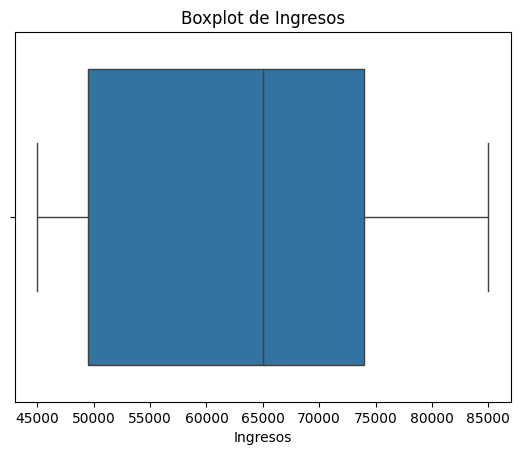

In [4]:
# Boxplot de Ingresos, ayuda a detectar outliers
sns.boxplot(x=df_cleaned["Ingresos"])
plt.title("Boxplot de Ingresos")
plt.show()

# No hay  presencia de outliers

In [5]:
# 2) Detección de outliers con IQR
Q1 = df_cleaned["Ingresos"].quantile(0.25)
Q3 = df_cleaned["Ingresos"].quantile(0.75)
IQR = Q3 - Q1

print("Primer Cuartil (Q1):", Q1)
print("Tercer Cuartil (Q3):", Q3)
print("Rango Intercuartílico (IQR):", IQR)

# Definir límites para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("\nLímite Inferior:", limite_inferior)
print("Límite Superior:", limite_superior)

# Filtrar valores dentro de los límites
df_cleaned = df_cleaned[(df_cleaned["Ingresos"] >= limite_inferior) & (df_cleaned["Ingresos"] <= limite_superior)]

print('\n---- Resultado de filtrar valores dentro de los límites')
print("Antes:", len(df), "Después:", len(df_cleaned))
#df_cleaned

Primer Cuartil (Q1): 49500.0
Tercer Cuartil (Q3): 74000.0
Rango Intercuartílico (IQR): 24500.0

Límite Inferior: 12750.0
Límite Superior: 110750.0

---- Resultado de filtrar valores dentro de los límites
Antes: 8 Después: 8


# **2. Transformación de Datos Numéricos**
**Normalizar Ingresos usando Min-Max Scaling.**

**Estandarizar Edad con Z-score Scaling.**

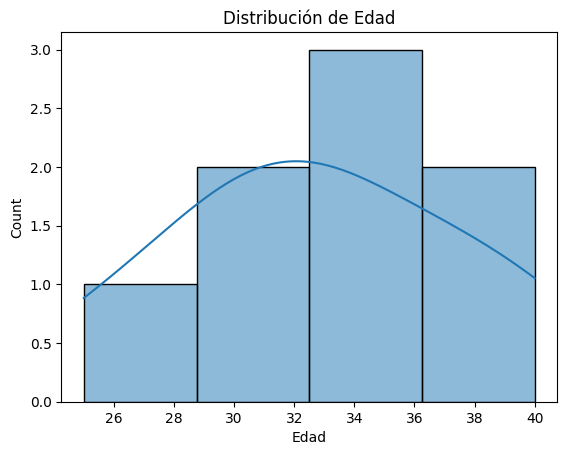

In [6]:
# Visualizar la distribución de 'Edad'
# La estandarización se aplica cuando los datos siguen una distribución normal
sns.histplot(df_cleaned["Edad"], kde=True)
plt.title("Distribución de Edad")
plt.show()

In [7]:
# Normalización de Ingresos usando "Min-Max Scaling"
scaler_minmax = MinMaxScaler()
df_cleaned["Ingresos_Normalizado"] = scaler_minmax.fit_transform(df_cleaned[["Ingresos"]])

# Estandarización de Edad con "Z-score"
scaler_std = StandardScaler()
df_cleaned["Edad_Estandarizada"] = scaler_std.fit_transform(df_cleaned[["Edad"]])

#print("Datos transformados:", df_cleaned)
print("Datos transformados:\n", df_cleaned[["Cliente", "Ingresos", "Ingresos_Normalizado", "Edad", "Edad_Estandarizada"]])

Datos transformados:
    Cliente  Ingresos  Ingresos_Normalizado  Edad  Edad_Estandarizada
0        1     50000                 0.125  25.0           -1.696245
1        2     60000                 0.375  40.0            1.586809
2        3     70000                 0.625  35.0            0.492458
3        4     80000                 0.875  32.5           -0.054718
4        5     45000                 0.000  30.0           -0.601893
5        6     85000                 1.000  32.5           -0.054718
6        7     72000                 0.675  38.0            1.149069
7        8     48000                 0.075  29.0           -0.820763


# **3. Transformación de Datos Categóricos**

**Aplicar One-Hot Encoding a la columna Historial de Pagos.**

**Aplicar Label Encoding a la columna Categoría.**

In [8]:
# Aplicar One-Hot Encoding a la columna Historial de Pagos
df_cleaned = pd.get_dummies(df_cleaned, columns=["Historial_Pagos"], prefix="Historial")

# Aplicar Label Encoding a la columna Categoría
le = LabelEncoder()
df_cleaned["Categoría_Label"] = le.fit_transform(df_cleaned["Categoría"])

print("Datos transformados:")
df_cleaned

Datos transformados:


,Cliente,Edad,Ingresos,Categoría,Ingresos_Normalizado,Edad_Estandarizada,Historial_Bueno,Historial_Malo,Historial_Regular,Categoría_Label
0,1,25.0,50000,A,0.125,-1.696245,True,False,False,0
1,2,40.0,60000,B,0.375,1.586809,False,False,True,1
2,3,35.0,70000,C,0.625,0.492458,False,True,False,2
3,4,32.5,80000,A,0.875,-0.054718,True,False,False,0
4,5,30.0,45000,B,0.000,-0.601893,False,False,True,1
5,6,32.5,85000,C,1.000,-0.054718,False,True,False,2
6,7,38.0,72000,A,0.675,1.149069,True,False,False,0
7,8,29.0,48000,B,0.075,-0.820763,False,False,True,1


# **4. Interacción con una Herramienta de IA (LLM)**
**Hacer una consulta a ChatGPT, Gemini u otra herramienta LLM sobre técnicas avanzadas de preprocesamiento de datos.**

Ejemplo de consulta: "¿Qué métodos avanzados de imputación de datos recomiendas para conjuntos de datos con muchas variables numéricas y categóricas?"

*Respuesta de Gemini*

Para datos numéricos y categóricos en un mismo dataset, los métodos más efectivos suelen ser:

* Imputación Múltiple por Ecuaciones Encadenadas (MICE): Un método estadístico robusto que modela cada variable con datos faltantes condicionalmente sobre otras variables del dataset, y luego imputa los valores basándose en esas predicciones. Es muy flexible y maneja bien diferentes tipos de datos. Genera múltiples datasets imputados para reflejar la incertidumbre de la imputación.

* k-Vecinos Más Cercanos (k-NN): Imputa valores faltantes buscando los 'k' registros más similares al registro con datos faltantes y utilizando los valores de esos vecinos para la imputación (media para numéricos, moda para categóricos). Funciona bien para datos numéricos y puede adaptarse para categóricos.

* Algoritmos Basados en Árboles (como RandomForestRegressor/Classifier): Entrenan un modelo de aprendizaje automático (por ejemplo, un Random Forest) para predecir los valores faltantes. Cada característica con valores ausentes se trata como una variable objetivo, y las demás características se utilizan como predictores. Este método captura relaciones complejas y no asume linealidad.

* Autoencoders (Redes Neuronales): Para datasets muy grandes y complejos, los autoencoders pueden aprender representaciones latentes de los datos y usarlas para reconstruir los valores faltantes. Son potentes pero requieren más recursos y datos.

La elección depende de la complejidad de los datos, la proporción de valores faltantes y los recursos computacionales.

**Comparar la respuesta con lo aprendido en la clase y reflexionar sobre su utilidad.**

*Comparación de Métodos mencionados:*

* MICE (Imputación Múltiple por Ecuaciones Encadenadas): en la clase lo menciona dentro de los "Modelos de imputación" como una técnica que predice valores basándose en otras variables cuando hay un patrón predecible. La respuesta de Gemini, profundiza en su naturaleza robusta y estadística, aclarando que genera múltiples datasets imputados para reflejar la incertidumbre.
* k-Vecinos Más Cercanos (k-NN): en la clase destaca su precisión cuando las variables tienen una correlación significativa. También se señala como ventaja que mantiene la consistencia de los datos, aunque requiere mayor costo computacional. En Gemini, explica el mecanismo, imputa valores faltantes buscando los 'k' registros más similares al registro con datos faltantes y utilizando los valores de esos vecinos para la imputación (media para numéricos, moda para categóricos).
* Algoritmos Basados en Árboles (Random Forest) y Autoencoders: en la clase se mencionan los modelos de árboles solo en el contexto de la codificación (Label Encoding) y las redes neuronales en relación con la normalización. No se describe su uso como herramientas para imputar datos faltantes. La respuesta de Gemini, dice que éstos se presentan como soluciones para capturar relaciones complejas y no lineales (Random Forest) o para datasets masivos (Autoencoders).
Reflexión sobre la Utilidad de estas Técnicas

*La utilidad de las diferentes técnicas, radica principalmente en la precisión vs. simplicidad:*

* La eliminación de filas puede hacer perder información útil. Los métodos MICE y  k-NN, permiten salvar el dataset sin introducir el sesgo que causaría una imputación simple por media o mediana, la cual puede distorsionar la distribución si hay muchos datos faltantes.
* Se dice que "datos sucios pueden generar errores". La utilidad de usar Random Forest o Autoencoders es que pueden identificar patrones ocultos que una mediana simple ignoraría totalmente, resultando en modelos de ML mucho más confiables.
* Si bien los modelos requieren mayor procesamiento computacional y validación, no siempre el método más complejo es el mejor si el dataset es pequeño o los recursos son limitados.
* El uso de k-NN o MICE asegura que el dato imputado sea "realista" en el contexto de las otras variables del registro, algo vital ya que un dato mal imputado podría introducir sesgo. Se debe garantizar la consistencia de los datos.


# Los resultados son publicados en el Foro.

